In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from heston.closed import heston_call_price
from black_scholes.bs import black_scholes

from neural_network.config import ModelConfig, HestonParams
from neural_network.trainer import HestonTrainer
from heston.tree import HestonTree

In [21]:
S0 = 100.0   # Initial stock price
K = 100.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
# kappa = 1e-6
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
# sigma = 1e-6
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

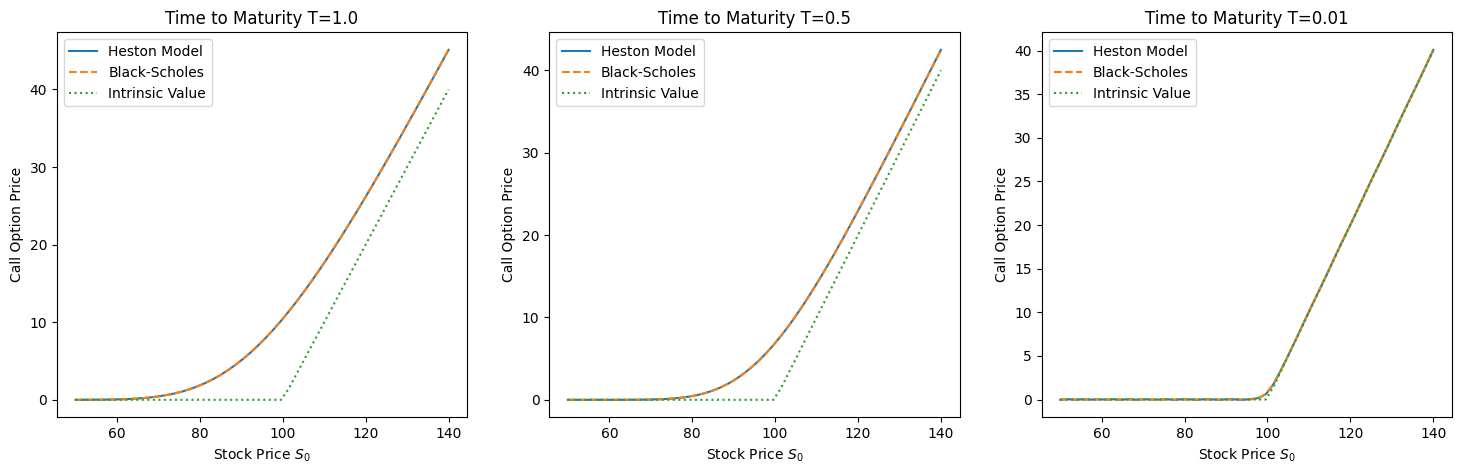

In [19]:
S = np.linspace(50, 140, 50)
intrinsic_values = np.maximum(S - K, 0)

Ts = [1.0, 0.5, 0.01]

plt.figure(figsize=(18, 5))
for i, T_ in enumerate(Ts):
    prices = [heston_call_price(S0, K, T_, r, kappa, theta, sigma, rho, v0) for S0 in S]
    bs_prices = [black_scholes(S0, K, r, np.sqrt(v0), T_, 'call') for S0 in S]
    plt.subplot(1, 3, i+1)
    plt.plot(S, prices, label='Heston Model')
    plt.plot(S, bs_prices, label='Black-Scholes', linestyle='--')
    plt.plot(S, intrinsic_values, label='Intrinsic Value', linestyle=':')
    plt.title(f'Time to Maturity T={T_}')
    plt.xlabel('Stock Price $S_0$')
    plt.ylabel('Call Option Price')
    plt.legend()
plt.show()

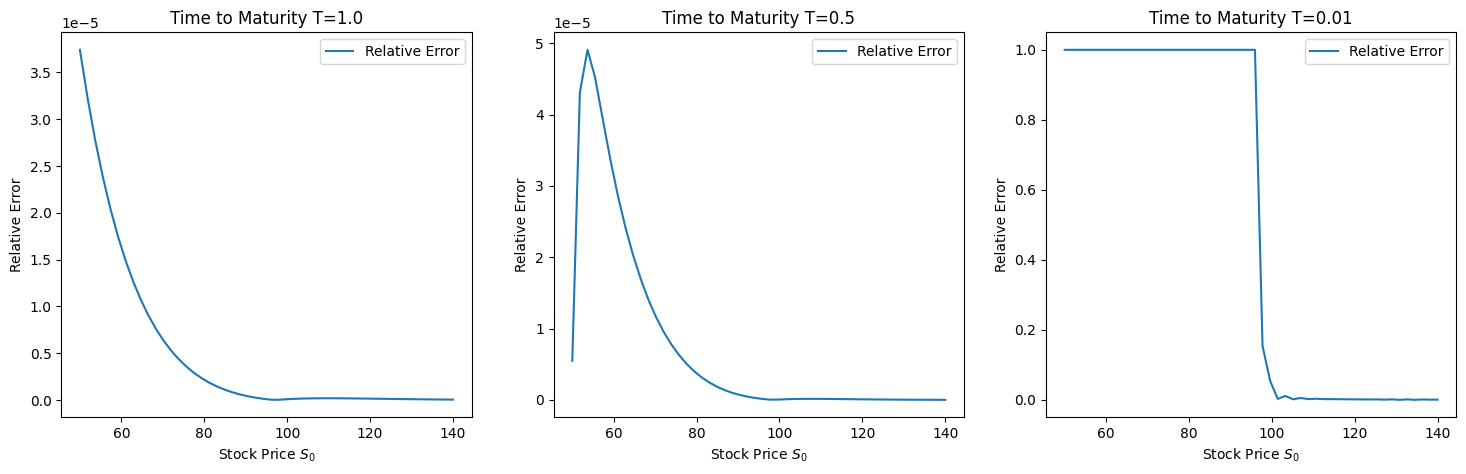

In [20]:
plt.figure(figsize=(18, 5))
for i, T_ in enumerate(Ts):
    prices = np.array([heston_call_price(S0, K, T_, r, kappa, theta, sigma, rho, v0) for S0 in S])
    bs_prices = np.array([black_scholes(S0, K, r, np.sqrt(v0), T_, 'call') for S0 in S])
    relative_errors = np.abs(prices - bs_prices) / bs_prices

    max_allowed_error = 1
    relative_errors = np.where(relative_errors < max_allowed_error, relative_errors, max_allowed_error)  # Filter small errors 
    plt.subplot(1, 3, i+1)
    plt.plot(S, relative_errors, label='Relative Error')
    plt.title(f'Time to Maturity T={T_}')
    plt.xlabel('Stock Price $S_0$')
    plt.ylabel('Relative Error')
    plt.legend()
plt.show()

## Closed form vs Tree

In [ ]:
n = 100
mz = 100
mv = 100
V0_min = 0.01
V0_max = 0.1
S0_min = 80
S0_max = 120
heston_tree = HestonTree(n, mz, mv, K, T, r, kappa, theta, sigma, rho)
heston_tree.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min, S0_max=S0_max)

In [ ]:
v0 = 0.04  # Fix initial variance
S = np.linspace(80, 120, 50)
prices = [heston_tree.price(v0, S0) for S0 in S]
bs_prices = [black_scholes(S0, K, r, np.sqrt(v0), T, 'call') for S0 in S]
closed_prices = [heston_call_price(S0, K, T, r, kappa, theta, sigma, rho, v0) for S0 in S]
plt.plot(S, prices, label='Heston Tree Prices')
plt.plot(S, closed_prices, label='Closed-form Heston Prices')
plt.plot(S, bs_prices, label='Black-Scholes Prices', linestyle='--')
plt.title('Heston Tree Option Prices vs Stock Price')
plt.xlabel('Stock Price $S_0$')
plt.ylabel('Call Option Price')
plt.legend()
plt.show()

## Neural network vs Closed form

In [ ]:
S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

S_max = 3 * S0
V_max = 0.5

params = HestonParams(
    S0=S0, v0=v0, r=r, kappa=kappa, theta=theta, sigma=sigma, rho=rho, T=T, K=K,
    S_max=S_max, V_max=V_max
)

model_config = ModelConfig(
    input_size=3,
    hidden_sizes=[64, 128, 128, 64],
    output_size=1,
    activation=nn.ReLU(),
    learning_rate=1e-4
)

loss_weights = {
    'pde': 5000.0,
    'payoff': 0.5,
    'S_min': 10.0,
    'S_max': 0.1,
    'V_min': 1000.0,
    'V_max': 0.01
}

heston_trainer = HestonTrainer(model_config=model_config, heston_params=params, payoff=None, loss_weights=loss_weights, seed=42)

In [ ]:
heston_trainer.train(batch_size=1024, epochs=10000, tol=1e-6)
heston_trainer.plot_losses_detailed()

In [ ]:
# grid resolution
num_S = 80
num_V = 80

Ss = np.linspace(0.01, S_max, num_S)
Vs = np.linspace(0, V_max, num_V)
t = 0

nn_prices = np.zeros((num_V, num_S))
cf_prices = np.zeros((num_V, num_S))

for i, v_val in enumerate(Vs):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = heston_trainer.predict(t, s_val, v_val).item()
        cf_prices[i, j] = heston_call_price(s_val, K, T - t, r, kappa, theta, sigma, rho, v_val)

In [ ]:
plt.figure(figsize=(17, 5))

plt.subplot(1, 3, 1)
vmax = np.abs(nn_prices).max()
vmin = -vmax
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='NN price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Neural Network Prices')

plt.subplot(1, 3, 2)
im2 = plt.imshow(cf_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im2, label='CF price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Closed Form Prices')

plt.subplot(1, 3, 3)
diff = nn_prices - cf_prices
vmax = np.abs(diff).max()*2
vmin = -vmax
im3 = plt.imshow(diff, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im3, label='NN price - CF price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Price difference')
plt.tight_layout()
plt.show()